In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [2]:
ds_sla = xr.open_dataset('SLA_UPDATED.nc')

In [3]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')

In [4]:
ocean_mask = ~ds_sla.sla.isel(time=0).isnull()

In [5]:
lat_idxs,lon_idxs = np.where(ocean_mask)

In [6]:
sla_now = ds_sla.sla

ds_ml = xr.Dataset({
        "sla_now": sla_now,
        
        **{
        f"sla_lag{i}": ds_sla.sla.shift(time=i)
        for i in range(1,15)
        },

        "tmp_surface": ds_gfs.TMP_surface,
        "tmp_2m": ds_gfs.TMP_2maboveground,

        "ugrd": ds_gfs.UGRD_10maboveground,
        "vgrd": ds_gfs.VGRD_10maboveground,

        "dswrf": ds_gfs.DSWRF_surface,
        "uswrf": ds_gfs.USWRF_surface,
        "dlwrf": ds_gfs.DLWRF_surface,
        "ulwrf": ds_gfs.ULWRF_surface,

        "spfh": ds_gfs.SPFH_2maboveground,
        "prate": ds_gfs.PRATE_surface,

        
    })
ds_ml["month"] = ds_ml.time.dt.month
ds_ml["dayofyear"] = ds_ml.time.dt.dayofyear

In [7]:
features = (
    ["sla_now"]
    + [f"sla_lag{i}" for i in range(1,15)]
    + [
        "tmp_surface",
        "tmp_2m",
        "ugrd",
        "vgrd",
        "dswrf",
        "uswrf",
        "dlwrf",
        "ulwrf",
        "spfh",
        "prate",
        "month",
        "dayofyear",
        "latitude",
        "longitude"
    ]
)

In [8]:
ds_ml = ds_ml.stack(
    point=("latitude","longitude")
)
df_features = (ds_ml.to_dataframe().reset_index()).dropna()

In [9]:
def build_Dataset(lead):

    target = ds_sla.sla.shift(time=-lead).where(ocean_mask).stack(point=("latitude","longitude"))
    
    target_df = target.to_dataframe(name="target").reset_index()
    
    df = df_features.merge(
    target_df,
    on=["time","latitude","longitude"]
    )
    
    df = df.dropna(subset=['target'])
    
    train = df[df.time < "2024-01-01"]
    test  = df[df.time >= "2024-01-01"]
    
    X_train = train[features]
    y_train = train["target"]
    X_test = test[features]
    y_test = test["target"]
    
    
    coords_test = test[["time", "latitude", "longitude"]]
    
    return X_train, y_train, X_test, y_test,coords_test

In [ ]:
def train_and_evaluate(lead):
    X_train, y_train, X_test, y_test,coords_test = build_Dataset(lead)
    model = XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)
    
    pred_xgb = model.predict(X_test)

    rmse_xgb = np.sqrt(
        mean_squared_error(
            y_test,
            pred_xgb
        )
    )
    pred_persistence = X_test["sla_now"]
    rmse_persistence = np.sqrt(
        mean_squared_error(
            y_test,pred_persistence
        )
    )
    
    error_df = X_test[['latitude', 'longitude']].copy()

    error_df['err_xgb'] = pred_xgb - y_test.values
    error_df["err_pers"] = pred_persistence.values - y_test.values
    
    pred_df = coords_test.copy()

    pred_df["truth"] = y_test.values
    pred_df["xgb"] = pred_xgb
    pred_df["pers"] = pred_persistence.values
    
    rmse_map = (
        error_df
        .groupby(["latitude","longitude"])
        .agg(
            rmse_xgb=("err_xgb",
                    lambda x: np.sqrt(np.mean(x**2))),
            rmse_pers=("err_pers",
                    lambda x: np.sqrt(np.mean(x**2)))
        )
        .reset_index()
    )
    
    rmse_map["improvement"] = (
        rmse_map["rmse_pers"]
        - rmse_map["rmse_xgb"]
    )
        
    return rmse_xgb, rmse_persistence, model, X_test,rmse_map,pred_df
    
    

Lead 1: Persistence=0.01848, XGB=0.01971
count    12475.000000
mean        -0.001111
std          0.001540
min         -0.045604
25%         -0.001294
50%         -0.000889
75%         -0.000612
max          0.012554
Name: improvement, dtype: float64


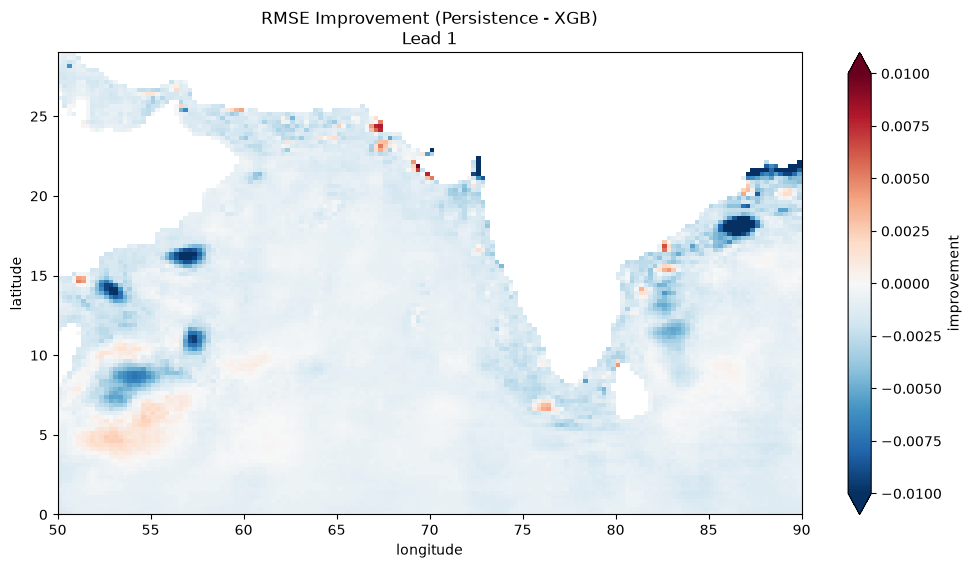

Lead 2: Persistence=0.02329, XGB=0.02497
count    12475.000000
mean        -0.001715
std          0.001980
min         -0.027183
25%         -0.002515
50%         -0.001677
75%         -0.000956
max          0.015818
Name: improvement, dtype: float64


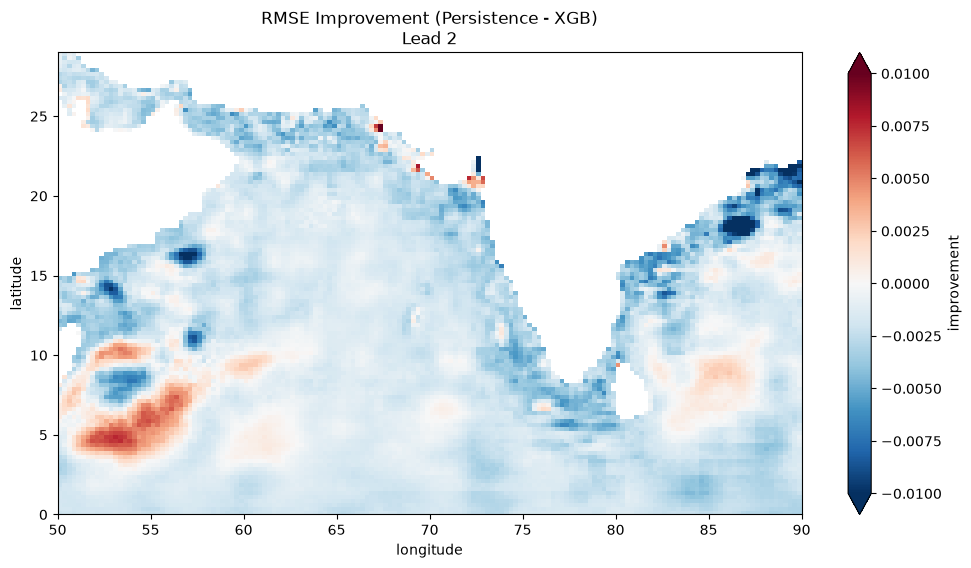

Lead 3: Persistence=0.02836, XGB=0.03028
count    12475.000000
mean        -0.002207
std          0.002659
min         -0.020640
25%         -0.003574
50%         -0.002415
75%         -0.001266
max          0.017270
Name: improvement, dtype: float64


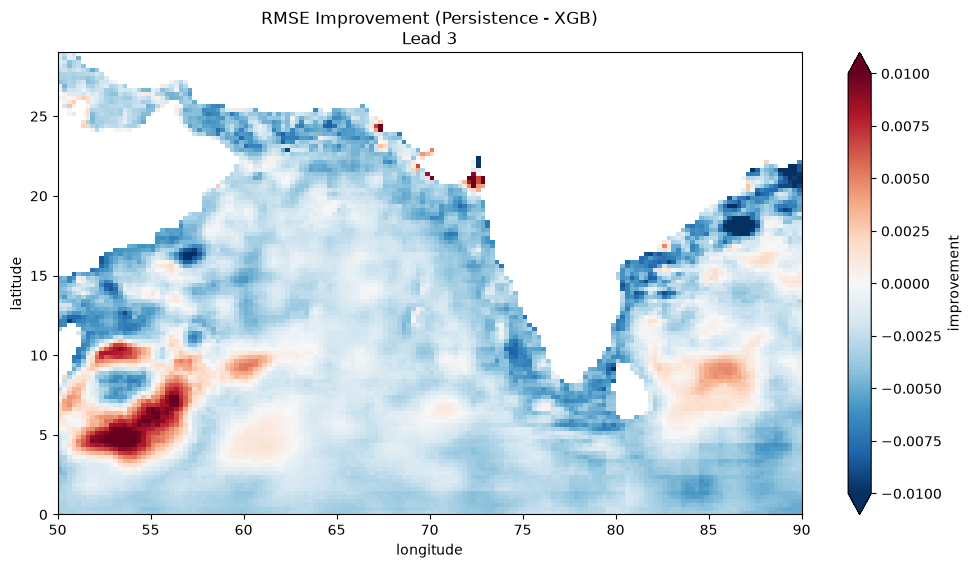

Lead 4: Persistence=0.03372, XGB=0.03519
count    12475.000000
mean        -0.002018
std          0.003363
min         -0.017625
25%         -0.003858
50%         -0.002438
75%         -0.001012
max          0.025911
Name: improvement, dtype: float64


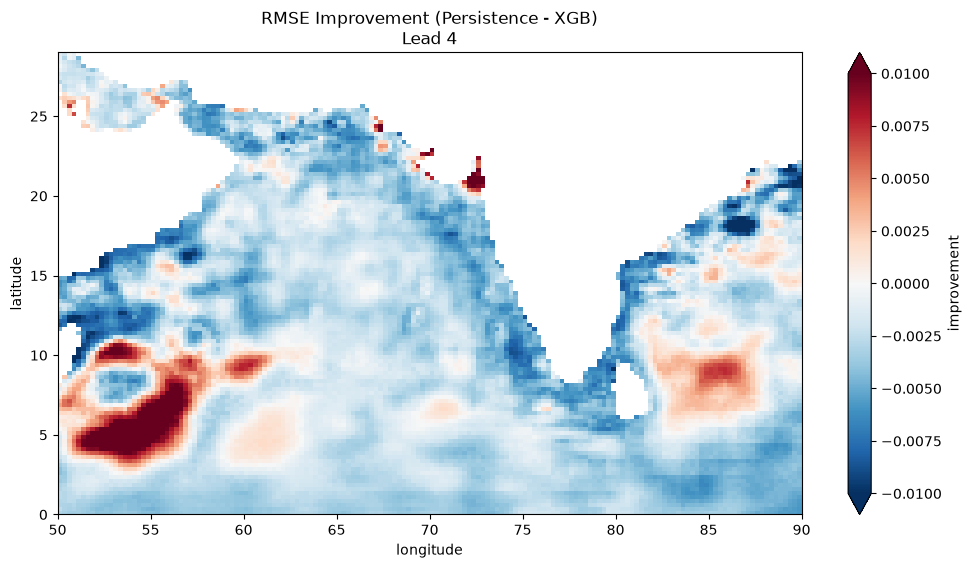

Lead 5: Persistence=0.03848, XGB=0.03905
count    12475.000000
mean        -0.001366
std          0.004150
min         -0.015161
25%         -0.003673
50%         -0.002029
75%         -0.000126
max          0.034051
Name: improvement, dtype: float64


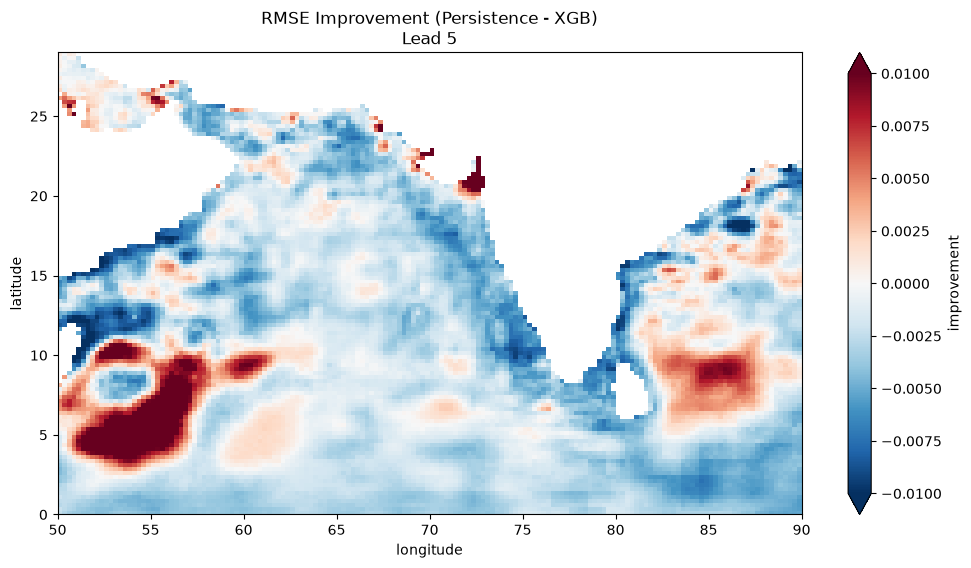

In [ ]:
results = []

for lead in range(1, 6):

    rmse_xgb, rmse_persistence, model, X_test,rmse_map,pred_df = train_and_evaluate(lead)

    results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_persistence
    })

    print(
        f"Lead {lead}: "
        f"Persistence={rmse_persistence:.5f}, "
        f"XGB={rmse_xgb:.5f}"
    )
    
    improvement_da = (
    rmse_map
    .set_index(["latitude","longitude"])
    ["improvement"]
    .to_xarray()
    )

    plt.figure(figsize=(12,6))

    improvement_da.plot(
        cmap="RdBu_r",
        vmin=-0.01,
        vmax=0.01
    )
    

    # Save RMSE table for this lead
    rmse_map.to_parquet(
        f"rmse_map_lead_{lead}.parquet"
    )

    # Save trained XGBoost model
    model.save_model(
        f"xgb_lead_{lead}.json"
    )

    # Save gridded improvement map
    improvement_da.to_netcdf(
        f"improvement_lead_{lead}.nc"
    )
    
    pred_df.to_parquet(
    f"predictions_lead_{lead}.parquet"
)
    
    plt.title(
        f"RMSE Improvement (Persistence - XGB)\nLead {lead}"
    )
    print(rmse_map["improvement"].describe())

    plt.show()

In [46]:
rmse_map.nlargest(5, "improvement")

,latitude,longitude,rmse_xgb,rmse_pers,improvement
11414,21.125,72.875,0.208481,0.242532,0.034051
11471,21.375,72.375,0.171279,0.199266,0.027987
11411,21.125,72.125,0.145325,0.172125,0.026800
11412,21.125,72.375,0.159483,0.186226,0.026743
11669,22.375,72.625,0.270593,0.296979,0.026386


In [50]:
eddy = rmse_map[
    (rmse_map.latitude.between(4, 6)) &
    (rmse_map.longitude.between(54, 56))
]

eddy.sort_values("improvement", ascending=False).head()

,latitude,longitude,rmse_xgb,rmse_pers,improvement
3701,5.875,55.375,0.063090,0.083977,0.020887
3699,5.875,54.875,0.067894,0.088718,0.020824
3700,5.875,55.125,0.066378,0.086914,0.020536
3539,5.625,54.875,0.065008,0.085314,0.020306
2896,4.625,54.125,0.057245,0.077304,0.020059


In [53]:
latx = 5.875
lony= 55.375

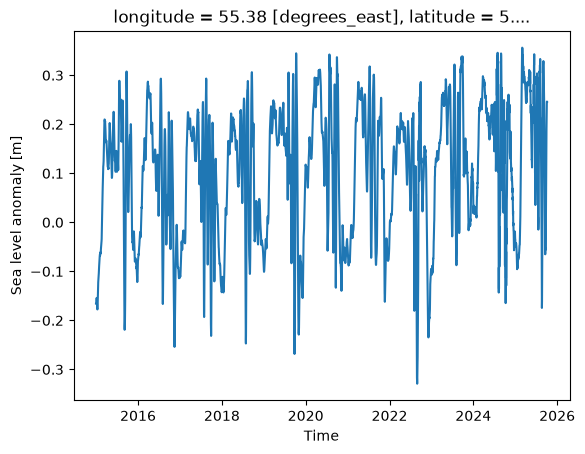

In [55]:
ds_sla.sla.sel(latitude=latx,longitude=lony).plot()

In [ ]:
point_df = pred_df[
    (pred_df.latitude == latx) &
    (pred_df.longitude == lony)
].sort_values("time")

In [12]:
ds_ml

<xarray.Dataset> Size: 7GB
Dimensions:      (time: 3930, point: 18560)
Coordinates:
  * time         (time) datetime64[ns] 31kB 2015-01-01 2015-01-02 ... 2025-10-05
  * point        (point) object 148kB MultiIndex
  * latitude     (point) float32 74kB 0.125 0.125 0.125 ... 28.88 28.88 28.88
  * longitude    (point) float32 74kB 50.12 50.38 50.62 ... 89.38 89.62 89.88
Data variables: (12/27)
    sla_now      (time, point) float32 292MB -0.0456 -0.0489 -0.0511 ... nan nan
    sla_lag1     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    sla_lag2     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    sla_lag3     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    sla_lag4     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    sla_lag5     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    ...           ...
    dlwrf        (time, point) float32 292MB 391.4 391.8 392.1 ... 286.8 282.7
    ulwrf        (time, point) float32 292MB 465.5 465.5 465.5 ... 347.1 339.1
    spfh         (time, point) float32 292MB 0.01619 0.01618 ... 0.006294
    prate        (time, point) float32 292MB 1.719e-06 1.594e-06 ... 5.367e-05
    month        (time) int64 31kB 1 1 1 1 1 1 1 1 1 ... 9 9 9 9 10 10 10 10 10
    dayofyear    (time) int64 31kB 1 2 3 4 5 6 7 ... 272 273 274 275 276 277 278

In [13]:
df_features.shape

(49141873, 30)

In [14]:
print(df_features.memory_usage(deep=True).sum() / 1024**3)

6.407370995730162


In [15]:
import psutil

print("Total RAM:", psutil.virtual_memory().total / 1024**3, "GB")
print("Available:", psutil.virtual_memory().available / 1024**3, "GB")

Total RAM: 62.40180969238281 GB
Available: 40.00222396850586 GB


In [16]:
fi = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(fi)

sla_now        0.626846
sla_lag1       0.219190
sla_lag3       0.034971
sla_lag2       0.029724
sla_lag4       0.016536
sla_lag8       0.006973
sla_lag7       0.006268
latitude       0.005351
sla_lag9       0.004727
sla_lag6       0.004454
sla_lag11      0.003665
sla_lag10      0.003554
sla_lag13      0.003351
sla_lag14      0.003212
longitude      0.003010
sla_lag12      0.002804
dayofyear      0.002754
ulwrf          0.002527
vgrd           0.002386
month          0.002221
prate          0.002202
sla_lag5       0.002175
tmp_surface    0.001955
ugrd           0.001934
dswrf          0.001699
dlwrf          0.001563
tmp_2m         0.001479
uswrf          0.001363
spfh           0.001104
dtype: float32


In [ ]:
error_map = error_df.pivot_table(
    index='latitude',
    columns='longitude',
    values='error_xg'
)

KeyError: 'error'

NameError: name 'error_map' is not defined

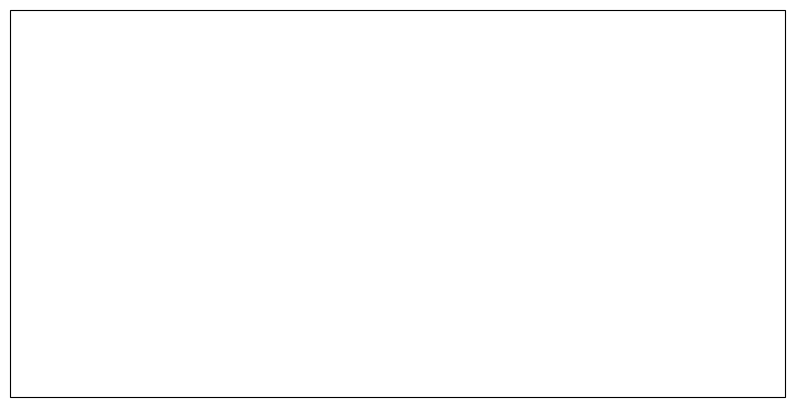

In [21]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    error_map.columns,
    error_map.index,
    error_map.values,
    cmap="RdBu_r",
    transform=ccrs.PlateCarree()
)

ax.coastlines()
plt.colorbar(pcm)

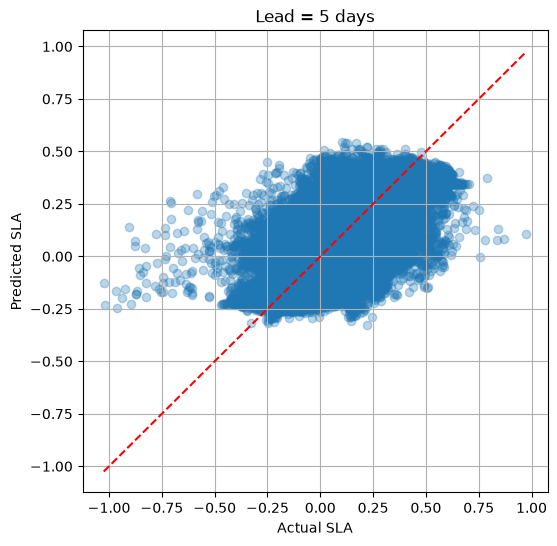

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_xgb, alpha=0.3)

mn = min(y_test.min(), pred_xgb.min())
mx = max(y_test.max(), pred_xgb.max())

plt.plot([mn,mx], [mn,mx], 'r--')
plt.xlabel("Actual SLA")
plt.ylabel("Predicted SLA")
plt.title(f"Lead = {lead} days")
plt.grid(True)
plt.show()

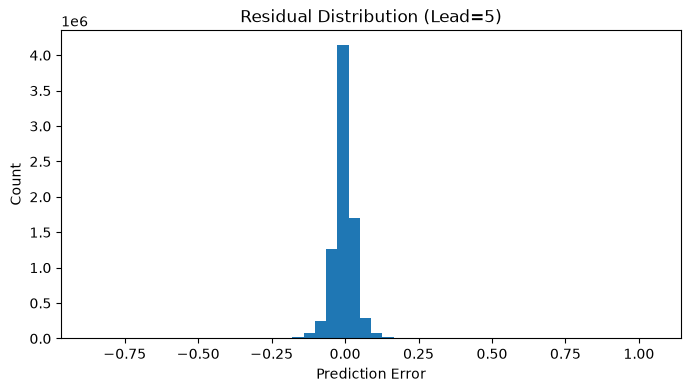

In [23]:
residuals = pred_xgb - y_test

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title(f"Residual Distribution (Lead={lead})")
plt.show()

In [24]:
persistence_pred = X_test["sla_now"]

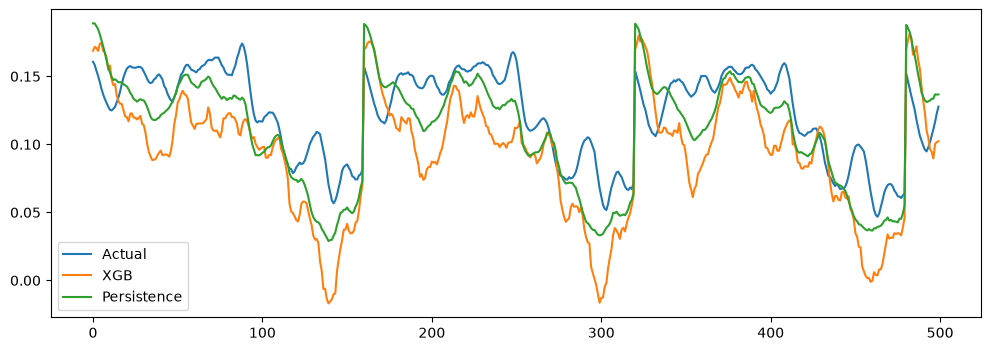

In [36]:
plt.figure(figsize=(12,4))
plt.plot(y_test.to_numpy()[:500], label="Actual")
plt.plot(pred_xgb[:500], label="XGB")
plt.plot(persistence_pred.to_numpy()[:500], label="Persistence")
plt.legend()
plt.show()

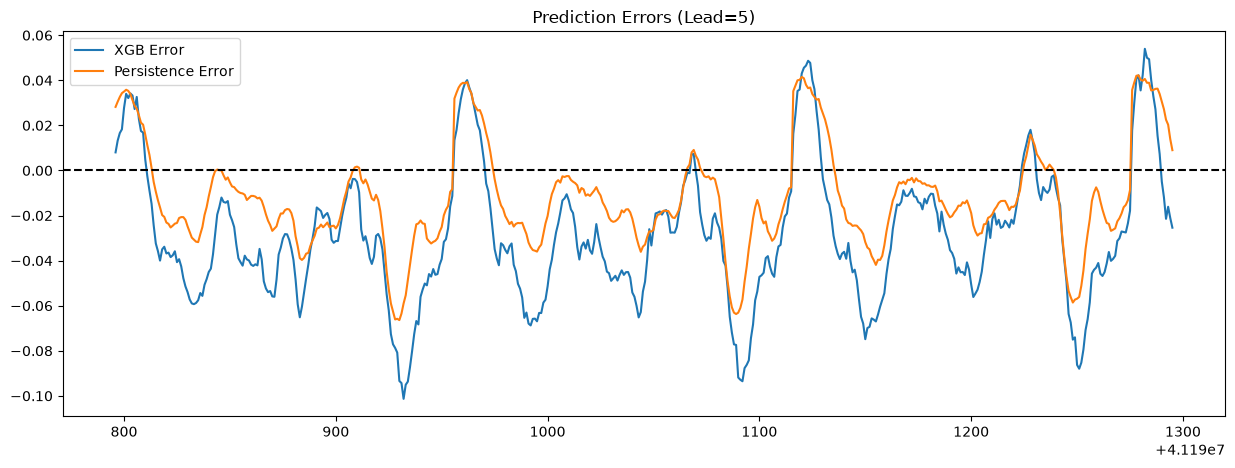

In [26]:
xgb_error = pred_xgb - y_test
pers_error = persistence_pred - y_test

plt.figure(figsize=(15,5))

plt.plot(xgb_error[:500], label='XGB Error')
plt.plot(pers_error[:500], label='Persistence Error')

plt.axhline(0, color='k', linestyle='--')
plt.legend()
plt.title(f"Prediction Errors (Lead={lead})")
plt.show()

In [57]:
results_df = pd.DataFrame(results)

In [58]:
results_df.to_csv(
    "lead_rmse_results.csv",
    index=False
)

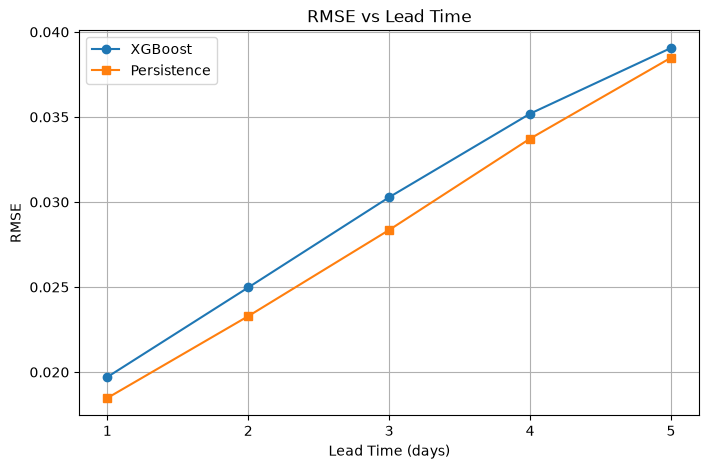

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["lead"],
    results_df["xgb"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    results_df["lead"],
    results_df["persistence"],
    marker="s",
    label="Persistence"
)

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE")
plt.title("RMSE vs Lead Time")
plt.xticks(results_df["lead"])
plt.grid(True)
plt.legend()

plt.show()

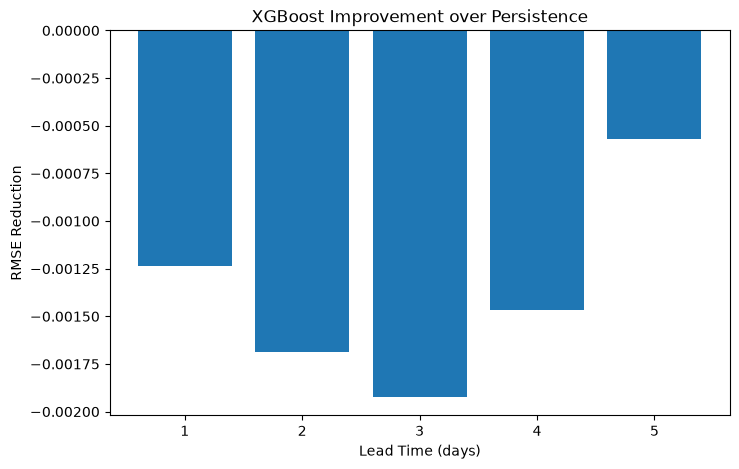

In [29]:
results_df["improvement"] = (
    results_df["persistence"] - results_df["xgb"]
)

plt.figure(figsize=(8,5))

plt.bar(
    results_df["lead"],
    results_df["improvement"]
)

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE Reduction")
plt.title("XGBoost Improvement over Persistence")

plt.show()

In [30]:
improvement = rmse_persistence - rmse_xgb

In [31]:
improvement_da = xr.DataArray(
    improvement,
    coords={
        "latitude": ds_sla.latitude,
        "longitude": ds_sla.longitude
    },
    dims=["latitude","longitude"]
)

plt.figure(figsize=(12,6))

improvement_da.plot(
    cmap="RdBu_r",
    vmin=-0.01,
    vmax=0.01
)

plt.title("RMSE Improvement (Persistence - XGB)")
plt.show()

ValueError: different number of dimensions on data and dims: 0 vs 2

In [33]:
xr.corr(
    rmse_xgb,
    rmse_persistence,
    dim="time"
)

TypeError: Only xr.DataArray is supported.Given [<class 'numpy.float64'>, <class 'numpy.float64'>].

In [34]:
rmse_xgb

np.float64(0.03905434225253729)

In [35]:
rmse_map

,latitude,longitude,rmse_xgb,rmse_pers,improvement
0,0.125,50.125,0.027252,0.024830,-0.002421
1,0.125,50.375,0.027119,0.024209,-0.002910
2,0.125,50.625,0.026924,0.023560,-0.003364
3,0.125,50.875,0.026784,0.023121,-0.003663
4,0.125,51.125,0.026458,0.022771,-0.003686
...,...,...,...,...,...
12470,28.625,51.125,0.049592,0.047254,-0.002338
12471,28.875,50.125,0.053478,0.054261,0.000783
12472,28.875,50.375,0.055035,0.054897,-0.000138
12473,28.875,50.625,0.051480,0.052355,0.000875
